<a href="https://colab.research.google.com/github/ardianita/data-science-2026/blob/main/Pertemuan_5_Ardianita_Fauziyah_250401020128.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Ardianita Fauziyah

NIM : 250401020128

Kelas : IF403

(344, 7) species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count          342.00         342.00             342.00       342.00
mean            43.92          17.15             200.92      4201.75
std              5.46           1.97              14.06       801.95
min             32.10          13.10             172.00      2700.00
25%             39.22          15.60             190.00      3550.00
50%             44.45          17.30             197.00      4050.00
75%             48.50          18.70             213.00      4750.00
max             59.60          21.50             231.00      6300.00


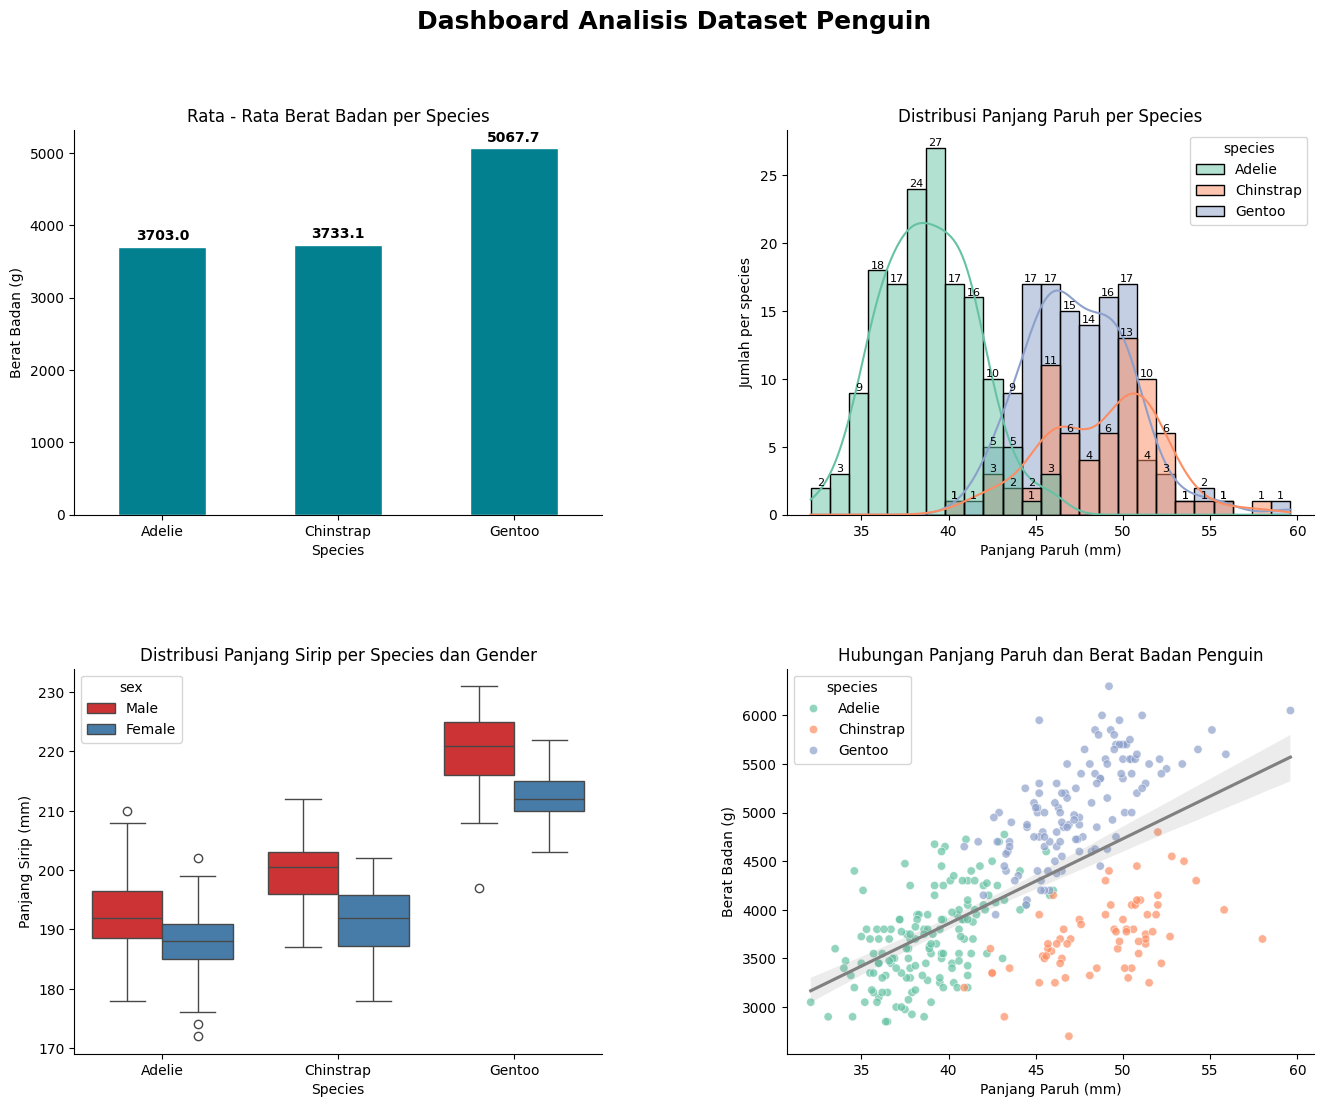

Dashboard tersimpan sebagai dashboard_penguins.png


In [ ]:
# ── TEMPLATE DASHBOARD VISUALISASI STATIS ────────────────────────────
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns

# ── 1. LOAD & INSPECT DATASET ──────────────────────────────────────────
df = sns.load_dataset('penguins')
print(df.shape, df.dtypes)
print(df.describe().round(2))

# Penanganan Missing Value
num_cols = [
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g'
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

df['sex'] = df['sex'].fillna(df['sex'].mode()[0])

# ── 2. SETUP FIGURE LAYOUT ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    'Dashboard Analisis Dataset Penguin',
    fontsize=18,
    fontweight='bold',
    y=0.98
)

# Grid 2 x 2 subplot
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])  # kiri atas
ax2 = fig.add_subplot(gs[0, 1])  # kanan atas
ax3 = fig.add_subplot(gs[1, 0])  # kiri bawah
ax4 = fig.add_subplot(gs[1, 1])  # kanan bawah

# ── 3. GRAFIK 1: Bar Chart ─────────────────────────────────────────────
avg_by_species = df.groupby('species')['body_mass_g'].mean()

avg_by_species.plot(
    kind='bar',
    ax=ax1,
    color='#028090',
    edgecolor='white',
    width=0.5
)

# Menambahkan nilai pada bar
for bar, val in zip(ax1.patches, avg_by_species.values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{val:.1f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax1.set_title('Rata - Rata Berat Badan per Species')
ax1.set_xlabel('Species')
ax1.set_ylabel('Berat Badan (g)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top', 'right']].set_visible(False)

# ── 4. GRAFIK 2: Histogram + KDE ───────────────────────────────────────
sns.histplot(
    data=df,
    x='bill_length_mm',
    hue='species',
    kde=True,
    palette='Set2',
    bins=25,
    ax=ax2
)

# Menambahkan nilai pada setiap bar
for patch in ax2.patches:
    height = patch.get_height()
    if height > 0:
        ax2.text(
            patch.get_x() + patch.get_width() / 2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=8
        )

ax2.set_title('Distribusi Panjang Paruh per Species')
ax2.set_xlabel('Panjang Paruh (mm)')
ax2.set_ylabel('Jumlah per species')
ax2.spines[['top','right']].set_visible(False)

# ── 5. GRAFIK 3: Boxplot ───────────────────────────────────────────────
sns.boxplot(
    data=df,
    x='species',
    y='flipper_length_mm',
    hue='sex',
    palette='Set1',
    ax=ax3
)
ax3.set_title('Distribusi Panjang Sirip per Species dan Gender')
ax3.set_xlabel('Species');
ax3.set_ylabel('Panjang Sirip (mm)')
ax3.spines[['top','right']].set_visible(False)

# ── 6. GRAFIK 4: Scatter Plot ──────────────────────────────────────────
sns.scatterplot(
    data=df,
    x='bill_length_mm',
    y='body_mass_g',
    hue='species',
    sizes=(30,180),
    palette='Set2',
    alpha=0.7,
    ax=ax4
)
sns.regplot(
    data=df,
    x='bill_length_mm',
    y='body_mass_g',
    scatter=False,
    color='gray',
    ax=ax4
)
ax4.set_title('Hubungan Panjang Paruh dan Berat Badan Penguin')
ax4.set_xlabel('Panjang Paruh (mm)')
ax4.set_ylabel('Berat Badan (g)')
ax4.spines[['top','right']].set_visible(False)

# ── 7. EKSPOR ──────────────────────────────────────────────────────────
plt.savefig('dashboard_penguins.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_penguins.png')

# **ANALISIS DASHBOARD DATASET PENGUIN**

**Rata-Rata Berat Badan Penguin per Species**
* **What** : Grafik diatas menunjukkan rata-rata berat badan penguin per spesies. Berdasarkan grafik diatas, rata-rata berat badan tertinggi diperoleh oleh penguin spesies ***Gentoo*** sedangkan yang terendah diperoleh oleh penguin species ***Adelie***.
* **So What** : Perbedaan berat badan menunjukkan adanya karakteristik biologis yang berbeda antar spesies. Berdasarkan grafik diatas, Penguin spesies ***Gentoo*** cenderung memiliki badan yang lebih besar. Sedangkan penguin spesies ***Adelie*** dan ***Chinstrap*** cenderung memiliki ukuran tubuh yang relatif kecil.
* **Now What** : Perbedaan berat badan antar spesies penguin perlu ditindaklanjuti dengan melakukan analisis lebih lanjut terhadap faktor-faktor yang memengaruhinya, seperti spesies, gender, pola makan, dan ukuran tubuh lainnya.


**Distribusi Panjang Paruh Penguin per Spesies**
* **What** : Histogram diatas menunjukkan distribusi panjang paruh penguin berdasarkan spesies. ***Adelie*** memiliki panjang paruh paling pendek, sedangkan ***Chinstrap*** memiliki panjang paruh paling panjang.
* **So What** : Panjang paruh dapat digunakan sebagai salah satu ciri utama untuk membedakan antar spesies penguin.
* **Now What** : Data panjang paruh ini dapat dimanfaatkan untuk analisis lebih lanjut, seperti mengelompokkan spesies penguin atau mencari hubungan antara panjang paruh dengan faktor lain.


**Distribusi Panjang Sirip per Spesies & Gender**
* **What** : Grafik ini menampilkan rentang panjang sirip (mm) yang dibedakan berdasarkan spesies dan jenis kelamin (jantan vs. betina). Pada ketiga spesies ini, penguin jantan secara konsisten memiliki panjang sirip yang lebih besar dibanding penguin betina..
* **So What** : Berdasarkan data ini terdapat perbedaan fisik berbasis gender yang sangat kuat dan konsisten pada seluruh spesies penguin, dimana penguin jantan selalu memiliki sirip lebih panjang.
* **Now What** : Data ini dapat digunakan untuk membantu identifikasi jenis kelamin penguin berdasarkan karakteristik fisiknya.

**Hubungan Panjang Paruh dan Berat Badan Penguin**
* **What** : Grafik scatterplot ini menampilkan korelasi antara panjang paruh dan berat badan dengan garis tren regresi yang menunjukkan hubungan positif.
* **So What** : Berdasarkan data tersebut menunjukkan bahwa semakin panjang paruh, semakin berat penguin. Namun, grafik ini mengungkap pola yang menarik pada ***Chinstrap*** yaitu mereka memiliki paruh yang panjang atau setara ***Gentoo*** tetapi bobot tubuhnya tetap ringan atau setara ***Adelie***.
* **Now What** : Data ini dapat digunakan untuk analisis lanjutan seperti membuat model prediksi berat badan penguin berdasarkan panjang paruh atau membantu proses klasifikasi spesies. Selain itu, analisis korelasi dapat dilakukan untuk mengetahui seberapa kuat hubungan antara kedua variabel tersebut.

**Kesimpulan**
* Pada praktikum ini saya mempelajari tentang bagaimana membuat dashboard. Langkah-langkahnya yaitu load dataset, handling missing value, set figure layout, dan create a chart. Di praktikum ini, saya membuat bar chart, historam beserta KDE nya, boxplot dan scatter plot dari dataset penguins.
* Pada praktikum ini saya menemukan bahwa dengan visualisasi mampu membantu mengidentifikasi pola atau informasi yang tersembunyi sehingga dapat dimanfaatkan untuk analisis lebih lanjut.
* Namun praktikum ini memiliki keterbatasan, yaitu masih berfokus pada analisis dan visualisasi data saja.